In [11]:
import kagglehub
path = kagglehub.dataset_download('muskanverma24/pothole-detection-dataset-yolov11-optimized')



100%|██████████| 215M/215M [00:06<00:00, 32.9MB/s]

Extracting files...


In [12]:
import os
print(os.listdir(path))

['README.dataset.txt', 'valid', 'data.yaml', 'test', 'README.roboflow.txt', 'train']


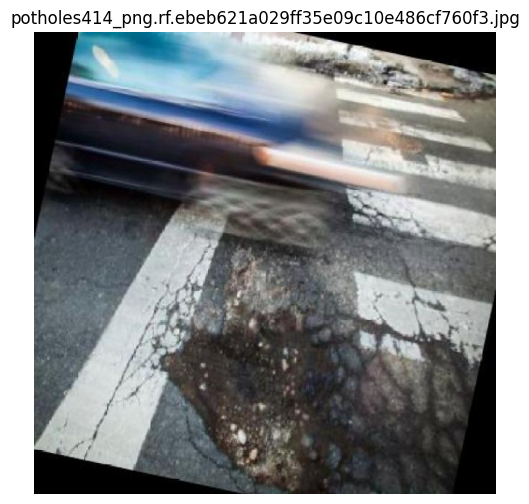

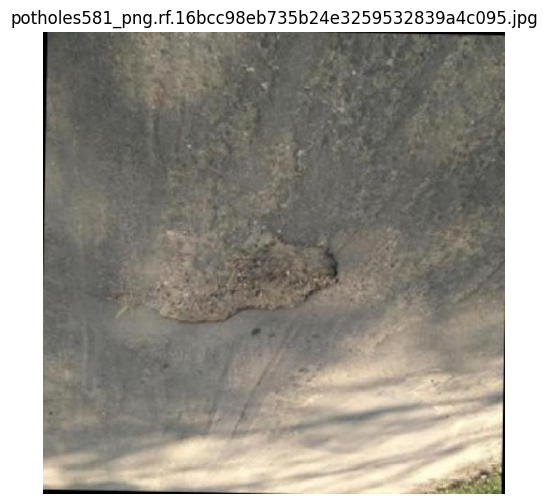

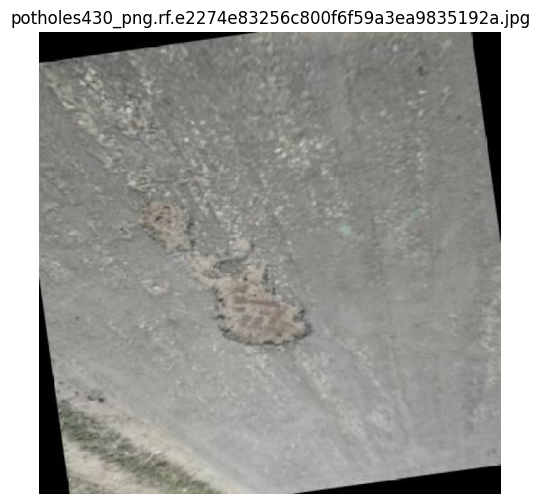

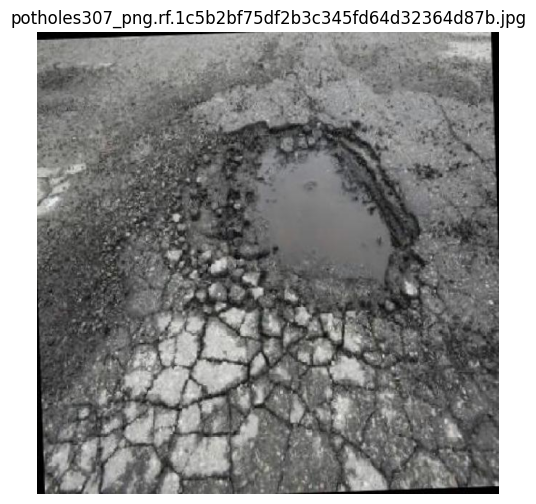

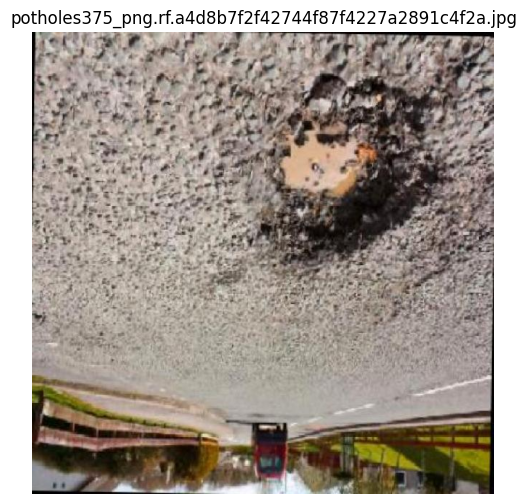

In [13]:
import cv2
import matplotlib.pyplot as plt
import os

# Set path to train images folder
train_images_path = os.path.join(path, 'train/images')
for i in range(5):
  first_image = os.listdir(train_images_path)[i]
  full_path = os.path.join(train_images_path, first_image)

  # Load and display the image
  img = cv2.imread(full_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(6, 6))
  plt.imshow(img)
  plt.axis('off')
  plt.title(first_image)
  plt.show()


In [14]:
!nvidia-smi

Tue Jul 21 20:18:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
%pip install  ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00


In [15]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [18]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')
result = model.train(data='/root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/data.yaml',
                     epochs=60,
                     imgsz=640 )

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic

In [19]:
# Validate the trained model (it automatically uses the best weights from training)

metrics = model.val()
print(metrics.box.image_metrics)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1758.3±584.2 MB/s, size: 52.0 KB)
val: Scanning /root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/valid/labels.cache... 397 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 397/397 118.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.9it/s 8.8s
                   all        397        973      0.869       0.84       0.91      0.644
Speed: 3.1ms preprocess, 11.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val
{'potholes64_png.rf.87fe440aeaf04a0ba3e729cecf77c4b0.jpg': {'precision': 0.3333333333333333, 'recall': 1.0, 'f1': 0.5, 'tp': 1, 'fp': 2, 'fn': 0}, 'potholes655_png.rf.c3d44e5770205578b7a88a8

In [20]:
#predict using test dataset
results = model.predict(
    source='/root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/test/images',
    save=True,
    conf=0.25
)


image 1/198 /root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/test/images/101_jpg.rf.ac03d0fc729e1fbbafb070d2ea30c9d9.jpg: 640x640 1 pothole, 15.4ms
image 2/198 /root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/test/images/111_jpg.rf.019e079da16b88cda78be0fc63c5de9c.jpg: 640x640 1 pothole, 15.5ms
image 3/198 /root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/test/images/114_jpg.rf.231877c4cda184b915d7bbce1fad65a8.jpg: 640x640 2 potholes, 15.5ms
image 4/198 /root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/test/images/117_jpg.rf.88fe8affec70765d35e71369f1853158.jpg: 640x640 1 pothole, 15.4ms
image 5/198 /root/.cache/kagglehub/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/versions/1/test/images/117_jpg.rf.f1f690cbe9439f8606ae3f441fd3dd60.jpg: 640x640 1 pothole, 15.5m

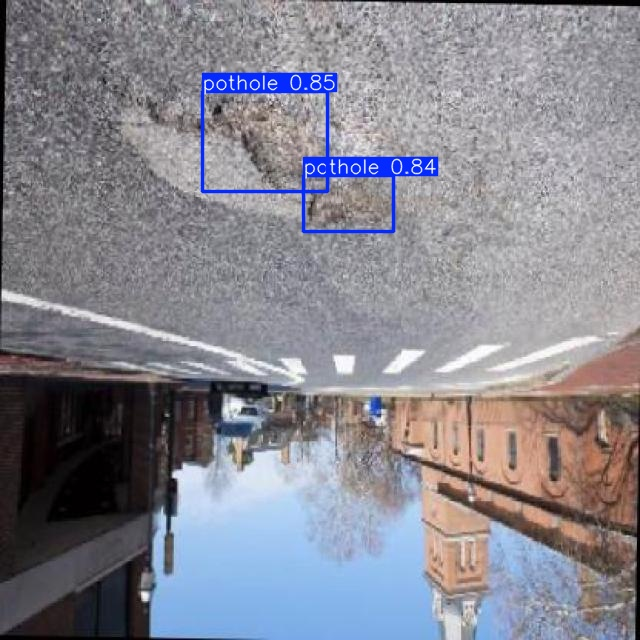

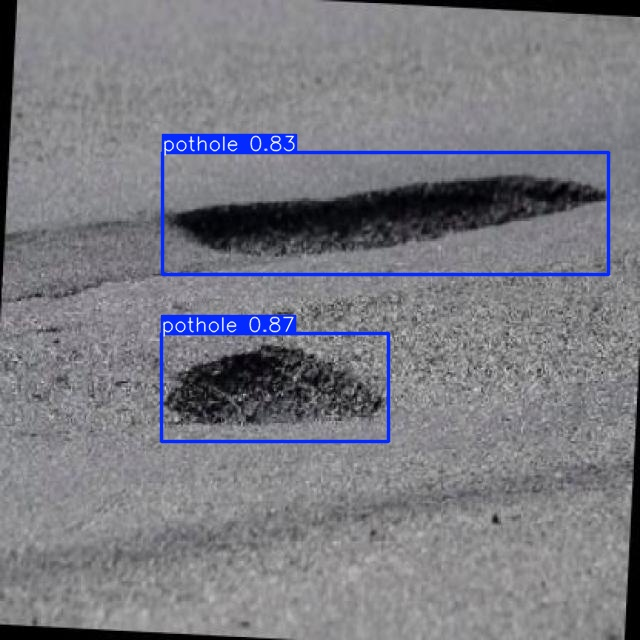

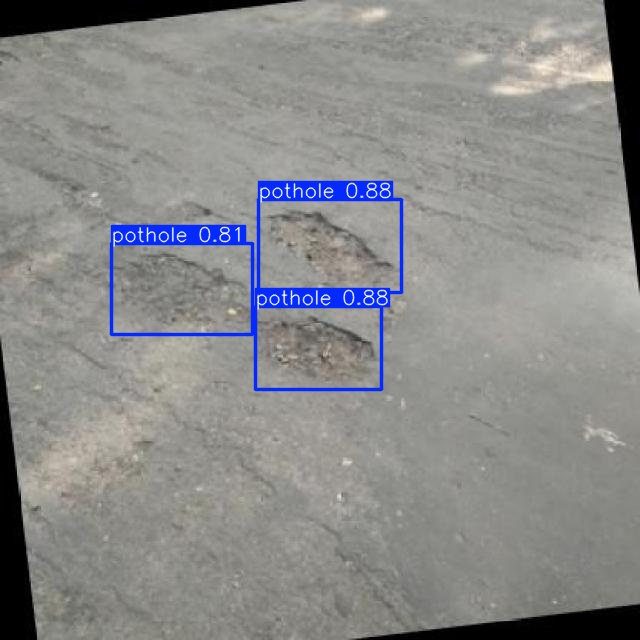

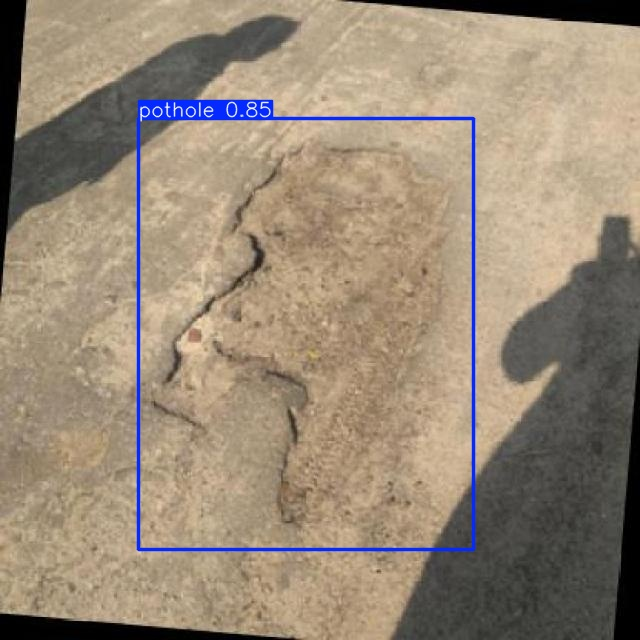

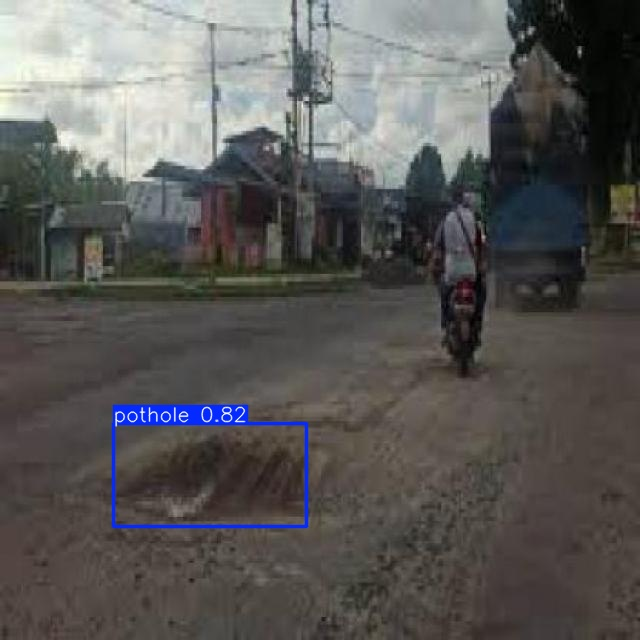

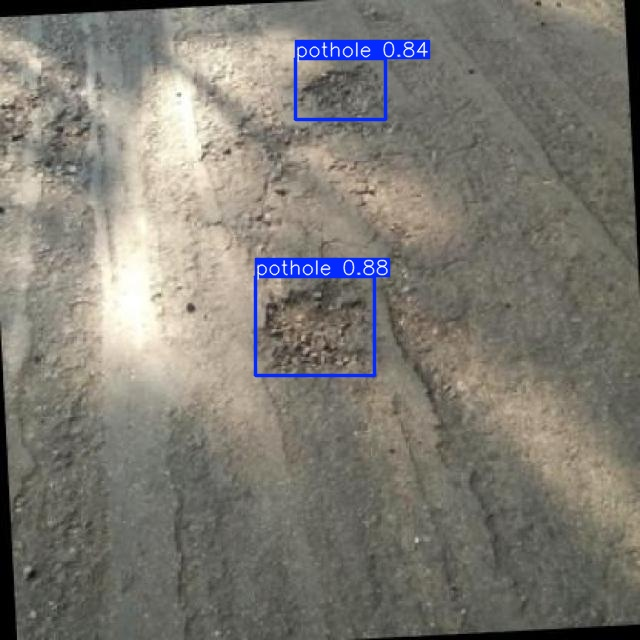

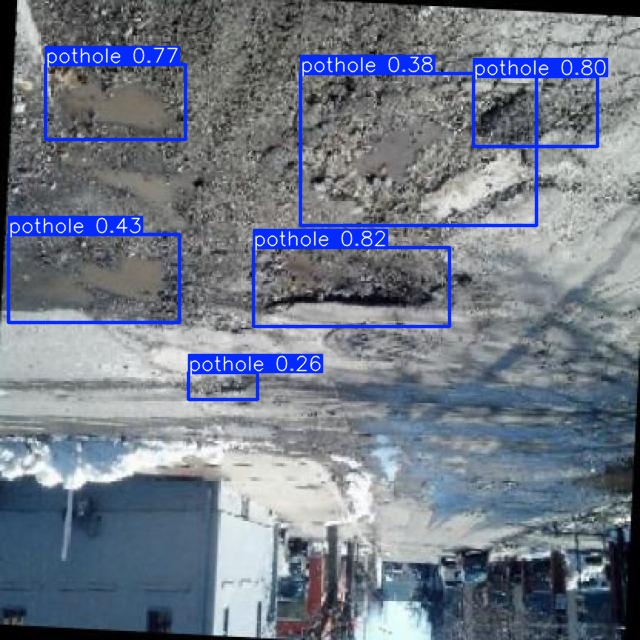

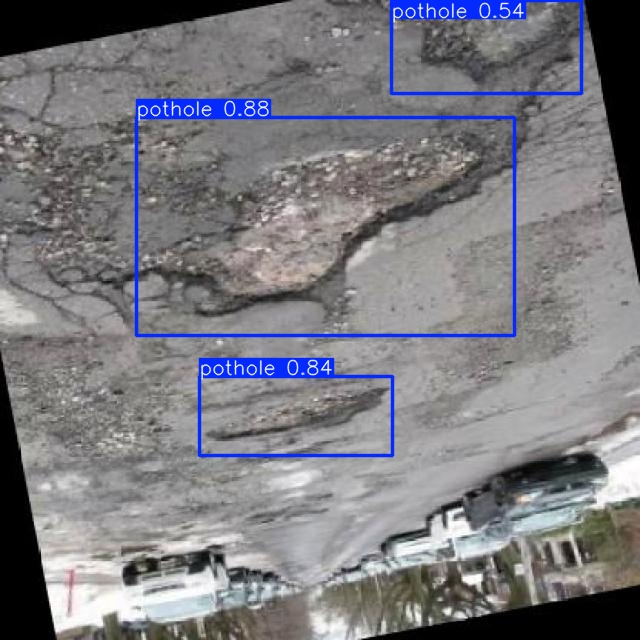

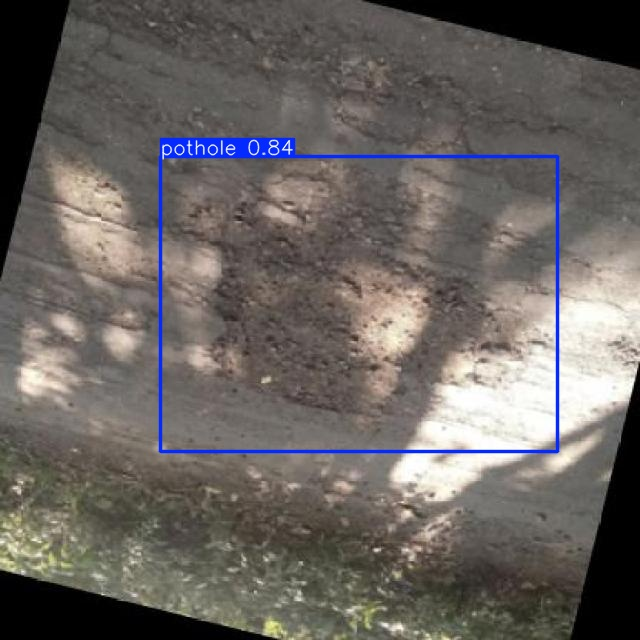

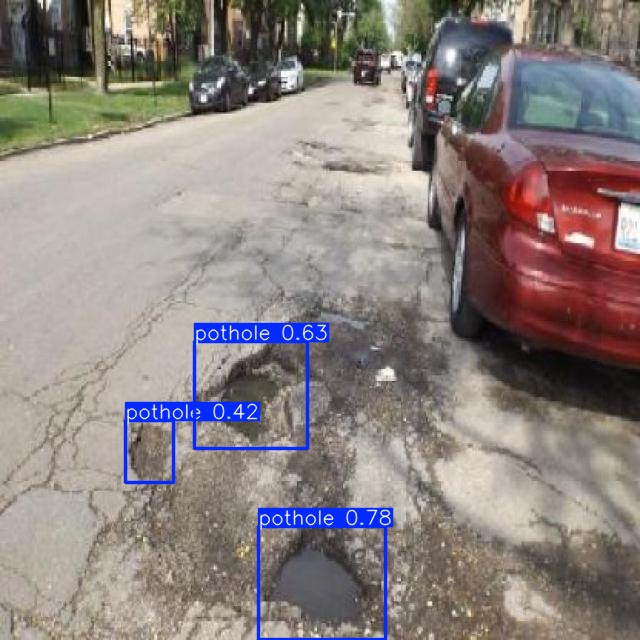

In [28]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=300))
  print('\n')

In [29]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/args.yaml (deflated 52%)
  adding: train/train_batch10502.jpg (deflated 5%)
  adding: train/train_batch0.jpg (deflated 2%)
  adding: train/train_batch10501.jpg (deflated 7%)
  adding: train/confusion_matrix_normalized.png (deflated 35%)
  adding: train/val_batch1_labels.jpg (deflated 5%)
  adding: train/val_batch0_labels.jpg (deflated 6%)
  adding: train/val_batch0_pred.jpg (deflated 6%)
  adding: train/val_batch2_pred.jpg (deflated 6%)
  adding: train/results.png (deflated 8%)
  adding: train/BoxR_curve.png (deflated 16%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/labels.jpg (deflated 30%)
  adding: train/confusion_matrix.png (deflated 34%)
  adding: train/train_batch1.jpg (deflated 3%)
  adding: train/train_batch10500.jpg (deflated 5%)
  adding: train/val_batch2_labels.jpg (deflated 6%)